### Step 1: Import crucial libraries. ###

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input

### Step 2: Load Data ###

In [5]:
#-- Load crucial file. --#
df_traffic = pd.read_csv('../Processed/Full_Traffic_With_Validity_Cleaned.csv')
df_efficiency = pd.read_csv('../Processed/efficiency_stations_cleaned.csv')

#-- Format 'Date' column to datetime type. --#
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])

#-- Sort by 'Date' and reset index. --#
df_traffic = df_traffic.sort_values(by='Date').reset_index(drop=True)

print(f"✅ Step 2 Complete!")
print(f"Sum of rows from dataset: {len(df_traffic)}")
print(f"Time range: From {df_traffic['Date'].min().date()} tos {df_traffic['Date'].max().date()}")

#-- Display the first few rows of the traffic DataFrame. --#
display(df_traffic.head())

✅ Step 2 Complete!
Sum of rows from dataset: 2883
Time range: From 2006-10-01 tos 2006-10-31


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total,Valid_Days
0,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.098120,10074,198,1,1,2006-10-01,...,34,28,28,14,14,15,12,5,4820,31
1,3120,BURKE_RD S of CANTERBURY_RD,045 J10,-37.82315,145.057240,16620,496,5,1,2006-10-01,...,98,90,75,55,68,42,41,39,9869,31
2,4273,TOORONGA_RD N of TOORAK_RD,059 F05,-37.84632,145.043780,4423,659,1,1,2006-10-01,...,30,23,21,21,16,18,9,14,4141,31
3,2200,MAROONDAH_HWY W of UNION_RD,046 H08,-37.81648,145.097739,6819,198,7,1,2006-10-01,...,48,37,46,42,29,24,19,20,6835,31
4,4821,VICTORIA_ST E OF BURNLEY_ST,002HF02,-37.81293,145.008650,16911,1513,3,1,2006-10-01,...,70,51,43,49,37,37,31,22,10060,31


### Step 3: EDA ###

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_7384\2013406238.py:12: SyntaxWarning: invalid escape sequence '\d'
  df_melted['Hour'] = df_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4


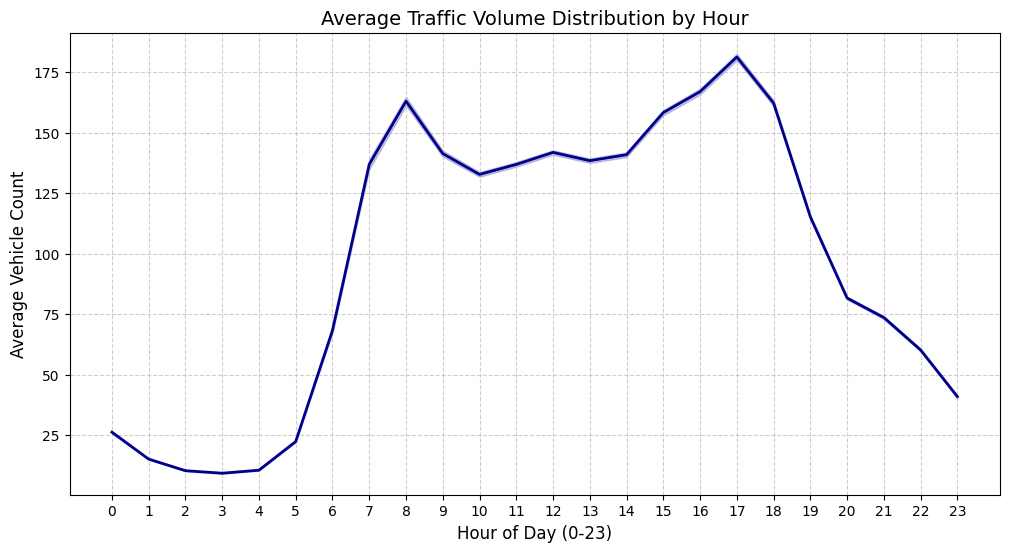

📊 Summary Statistics for Traffic Volume:
count    276768.000000
mean         97.347710
std          80.593898
min           0.000000
25%          23.000000
50%          88.000000
75%         148.000000
max         535.000000
Name: Volume, dtype: float64


In [6]:
#-- Melt the dataset from wide (V00-V95) to long format. --#
v_cols = [f'V{i:02d}' for i in range(96)]
df_melted = df_traffic.melt(
    id_vars=['Date', 'SCATS Number', 'Location'], 
    value_vars=v_cols, 
    var_name='Time_Slot', 
    value_name='Volume'
)

#-- Extract Hour from Time_Slot (Each slot represents 15 minutes). --#
# Example: V00-V03 = Hour 0, V04-V07 = Hour 1...
df_melted['Hour'] = df_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4

#-- Visualization: Average Traffic Volume by Hour. --#
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Hour', y='Volume', estimator='mean', color='darkblue', linewidth=2)

plt.title('Average Traffic Volume Distribution by Hour', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Vehicle Count', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

#-- Save the plot to Figures folder. --#
if not os.path.exists('../Figures'):
    os.makedirs('../Figures')
plt.savefig('../Figures/Traffic_Volume_EDA.png')
plt.show()

# 5. Display data statistics
print("📊 Summary Statistics for Traffic Volume:")
print(df_melted['Volume'].describe())

### Step 4: Feature Engineering ###

In [7]:
#-- Temporal Features: Extract Day of Week (0=Mon, 6=Sun) and IsWeekend flag. --3
df_melted['DayOfWeek'] = df_melted['Date'].dt.dayofweek
df_melted['IsWeekend'] = df_melted['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#-- Integrate Metadata: Using average Efficiency Index and AADT from the metadata file. --#
# Note: Ensure df_efficiency was loaded in Step 2
avg_efficiency = df_efficiency['efficiency_index'].mean()
avg_aadt = df_efficiency['road_avg_aadt'].mean()

df_melted['Efficiency_Index'] = avg_efficiency
df_melted['Road_Avg_AADT'] = avg_aadt

#-- Final Check of the engineered features. --#
print("✅ Step 4 Complete: Features Engineered.")
print(f"Features: Hour, DayOfWeek, IsWeekend, Efficiency_Index, Road_Avg_AADT")
display(df_melted.head())

✅ Step 4 Complete: Features Engineered.
Features: Hour, DayOfWeek, IsWeekend, Efficiency_Index, Road_Avg_AADT


,Date,SCATS Number,Location,Time_Slot,Volume,Hour,DayOfWeek,IsWeekend,Efficiency_Index,Road_Avg_AADT
0,2006-10-01,2200,UNION_RD N of MAROONDAH_HWY,V00,25,0,6,1,2.507638,3793.262963
1,2006-10-01,3120,BURKE_RD S of CANTERBURY_RD,V00,105,0,6,1,2.507638,3793.262963
2,2006-10-01,4273,TOORONGA_RD N of TOORAK_RD,V00,15,0,6,1,2.507638,3793.262963
3,2006-10-01,2200,MAROONDAH_HWY W of UNION_RD,V00,47,0,6,1,2.507638,3793.262963
4,2006-10-01,4821,VICTORIA_ST E OF BURNLEY_ST,V00,44,0,6,1,2.507638,3793.262963


### Step 5: Data Scaling and Sequence Preparation ###

In [8]:
#-- Select feature columns for the model. --#
# Target is 'Volume' (index 0), others are exogenous variables
feature_cols = ['Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']
data_array = df_melted[feature_cols].values

#-- Scale data to range [0, 1] for faster convergence. --#
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_array)

#-- Create Sliding Window Sequences (Window Size = 96 slots = 24 hours). --#
def create_sequences(data, window_size=96):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # Input: past 96 steps
        y.append(data[i, 0])              # Output: current Volume
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data)

#-- Split data into Training (80%) and Testing (20%). --#
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"✅ Step 5 Complete!")
print(f"X_train shape: {X_train.shape}") 
print(f"X_test shape: {X_test.shape}")

✅ Step 5 Complete!
X_train shape: (221337, 96, 6)
X_test shape: (55335, 96, 6)


### Step 6: Build and Train Model ###

In [9]:
model_blstm = Sequential([
    # Input shape lấy từ X_train đã tạo qua Sliding Window (96, 10)
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # Layer 1: Bidirectional LSTM - Học cả chiều quá khứ và tương lai
    Bidirectional(LSTM(units=100, return_sequences=True)),
    Dropout(0.2),
    
    # Layer 2: Bidirectional LSTM - Kết xuất đặc trưng quan trọng
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dropout(0.2),
    
    # Dense Layers để ra kết quả cuối cùng
    Dense(units=25, activation='relu'),
    Dense(units=1) 
])

# 2. Compile model với Adam Optimizer
model_blstm.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='mse', 
    metrics=['mae']
)

model_blstm.summary()
print("✅ Model has been built finished")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 96, 200)        │        85,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,551 (736.53 KB)

 Trainable params: 188,551 (736.53 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model has been built finished


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

print("🚀 Start Training")
history = model_blstm.fit(
    X_train, y_train,
    epochs=10,               
    batch_size=64, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("-" * 30)
print("✅ Training finished!")

final_mae = model_blstm.evaluate(X_test, y_test, verbose=0)[1]
print(f"📊 MAE Final: {final_mae:.4f}")

🚀 Start Training
Epoch 1/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 414s 120ms/step - loss: 0.0103 - mae: 0.0691 - val_loss: 0.0159 - val_mae: 0.1095
Epoch 2/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 475s 137ms/step - loss: 0.0102 - mae: 0.0684 - val_loss: 0.0168 - val_mae: 0.1127
Epoch 3/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 647s 187ms/step - loss: 0.0102 - mae: 0.0684 - val_loss: 0.0163 - val_mae: 0.1101
Epoch 4/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 458s 132ms/step - loss: 0.0101 - mae: 0.0682 - val_loss: 0.0191 - val_mae: 0.1189
Epoch 5/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 440s 127ms/step - loss: 0.0100 - mae: 0.0680 - val_loss: 0.0234 - val_mae: 0.1340
Epoch 6/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 442s 128ms/step - loss: 0.0099 - mae: 0.0675 - val_loss: 0.0184 - val_mae: 0.1164
Epoch 7/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 408s 118ms/step - loss: 0.0098 - mae: 0.0672 - val_loss: 0.0267 - val_mae: 0.1431
Epoch 8/10
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 509s 147ms/step - loss: 0.0097 - mae: 0.0666 - val_loss: 0.0181 - val_mae

### Step 7: Modeel Evaluation ###

1730/1730 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step
------------------------------
📊 KẾT QUẢ EVALUATION:
- Mean Absolute Error (MAE): 0.1095
- Root Mean Squared Error (RMSE): 0.1262
------------------------------


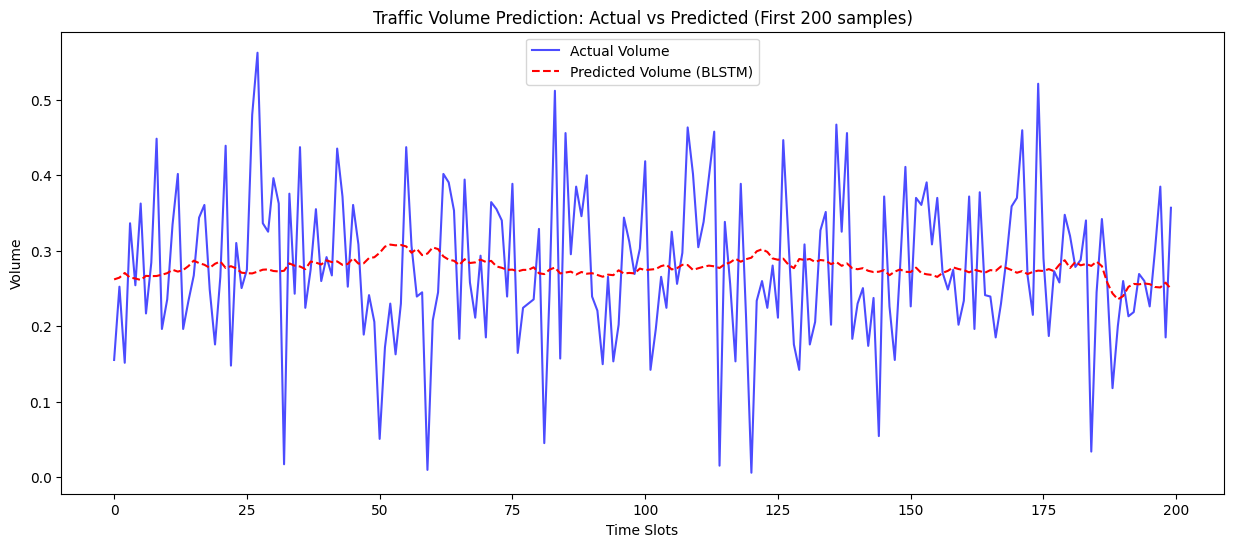

In [11]:
y_pred = model_blstm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("-" * 30)
print(f"📊 KẾT QUẢ EVALUATION:")
print(f"- Mean Absolute Error (MAE): {mae:.4f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-" * 30)

plt.figure(figsize=(15, 6))
plt.plot(y_test[:200], label='Actual Volume', color='blue', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Volume (BLSTM)', color='red', linestyle='--')
plt.title('Traffic Volume Prediction: Actual vs Predicted (First 200 samples)')
plt.xlabel('Time Slots')
plt.ylabel('Volume')
plt.legend()
plt.show()

### Step 8: Generate test Case ###

In [12]:
df = pd.read_csv('../Processed/Full_Traffic_With_Validity_Cleaned.csv')

test_source = df.sample(frac=0.2, random_state=42)

output_dir = '../../TestCase'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Đã tạo thư mục: {output_dir}")

start_num = 7
for i in range(4):
    sample_10 = test_source.iloc[i*10 : (i+1)*10]
    
    file_name = f'BLSTTest{start_num + i:02d}.csv'
    file_path = os.path.join(output_dir, file_name)
    
    sample_10.to_csv(file_path, index=False)
    print(f"💾 Saved: {file_path}")

print("-" * 30)
print("🚀 Success")


💾 Saved: ../../TestCase\BLSTTest07.csv
💾 Saved: ../../TestCase\BLSTTest08.csv
💾 Saved: ../../TestCase\BLSTTest09.csv
💾 Saved: ../../TestCase\BLSTTest10.csv
------------------------------
🚀 Success


### Step 9: Test ##

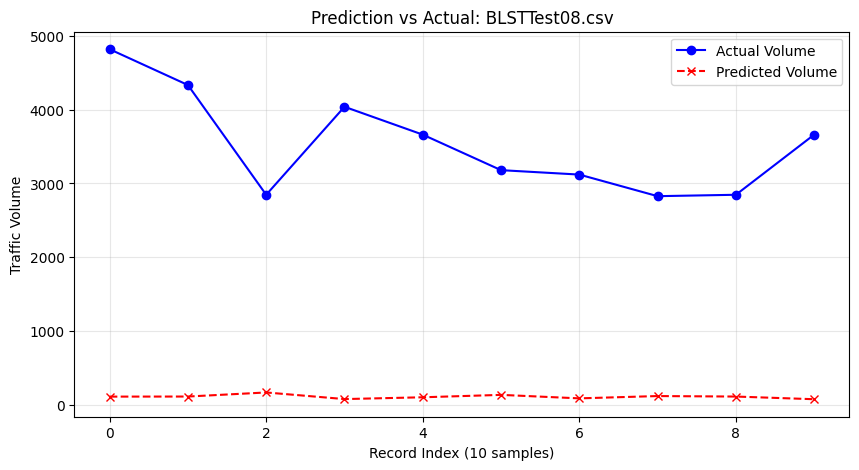

----------------------------------------
✅ Plot generated for 10 records.


In [29]:
file_path = '../../TestCase/BLSTTest08.csv'

if not os.path.exists(file_path):
    print(f"❌ Error: File not found at {file_path}")
else:
    df_test = pd.read_csv(file_path)
    
    try:
        # 2. Extract features based on scaler's expected count
        expected_count = scaler.n_features_in_
        numeric_cols = df_test.select_dtypes(include=[np.number])
        input_raw = numeric_cols.iloc[:, :expected_count].values
        
        # 3. Store actual values (Target is usually the first column 'V00')
        actual_values = input_raw[:, 0] 
        
        # 4. Scaling and Preparation
        scaled_data = scaler.transform(input_raw)
        window_size = 96
        
        predictions_list = []

        # 5. Loop through each record in the test file to get predictions
        for i in range(len(scaled_data)):
            # Create a window by tiling the current record
            current_row = scaled_data[i:i+1, :]
            input_sequence = np.tile(current_row, (1, window_size, 1))
            
            # Predict
            pred_scaled = model_blstm.predict(input_sequence, verbose=0)
            
            # Inverse scale to get real volume
            dummy = np.zeros((1, expected_count))
            dummy[0, 0] = pred_scaled[0][0]
            final_pred = scaler.inverse_transform(dummy)[0, 0]
            predictions_list.append(final_pred)

        # 6. Visualization
        plt.figure(figsize=(10, 5))
        plt.plot(actual_values, label='Actual Volume', marker='o', color='blue', linestyle='-')
        plt.plot(predictions_list, label='Predicted Volume', marker='x', color='red', linestyle='--')
        
        plt.title(f'Prediction vs Actual: {os.path.basename(file_path)}')
        plt.xlabel('Record Index (10 samples)')
        plt.ylabel('Traffic Volume')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        print("-" * 40)
        print(f"✅ Plot generated for {len(predictions_list)} records.")

    except Exception as e:
        print(f"❌ Error Detail: {str(e)}")

In [11]:
import joblib
import os

# 1. Create the directory structure
model_dir = '../../Model'

# 2. Save all trained models
# Make sure these variables exist in your current notebook
model_blstm.save(f'{model_dir}/model_blstm.keras')

# 3. Save the Scaler
joblib.dump(scaler, f'{model_dir}/scaler.pkl')

print("✅ Saved everything to Model folder!")

✅ Saved everything to Model folder!
